In [1]:
from option_chain_downloader import OptionChainDownloader
from option_finder import *
from option_data_plotter import *
import matplotlib.pyplot as plt

In [2]:
try:
    logger
except NameError:
    logger = get_rotating_logger("jupyter", f'logs/leaps_latest.log')

In [3]:
chain_dir = 'chain'
quotes_dir = 'quotes'
leaps_dir = 'leaps'
data_dir = 'data'
cookie_file = 'cookie.txt'
ocd = OptionChainDownloader(chain_dir, quotes_dir, leaps_dir, cookie_file, logger, strikes='ALL')
self = OptionFinder(logger, chain_dir=leaps_dir, report_dir=data_dir)

In [4]:
#symlist = ['GLD', 'QQQ'] # TLT GLD IBIT'.split(' ')
symlist = 'QQQ SPY TLT DIA IBIT ETHA GLD CRCL NVDA MSFT GOOGL AAPL'.split(' ')
#symlist = 'TSM NVDA AAPL MSFT GOOGL AMZN META TSLA'.split(' ')
#symlist = 'QQQ SPY TLT DIA IBIT GLD'.split(' ')

## Refresh data here

In [9]:
_t0 = time.time()
_n = ocd.download_option_chain(symlist, batch_size=5, rps=5)
print(_n, 'files downloaded', int(time.time() - _t0), 'seconds')

36 files downloaded 7 seconds


dte,107,118,135,148,163,177,197,209,226,289,301,380,408,471
expDt,2026-03-20,2026-03-31,2026-04-17,2026-04-30,2026-05-15,2026-05-29,2026-06-18,2026-06-30,2026-07-17,2026-09-18,2026-09-30,2026-12-18,2027-01-15,2027-03-19


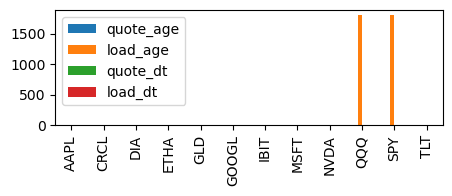

In [10]:
self.get_quote_df(symlist)
_df = self.build_option_df(symlist)
df_cp = self.concat_put_call_options(_df)
df_cp['pctTheta'] = df_cp.Theta*100/df_cp.mid
plt.rcParams['figure.figsize'] = (5, 1.5)
check_data_age(_df).plot(kind='bar', xlabel="")
df_cp.loc[:, ['dte', 'expDt']].groupby('dte').first().T

### Puts/calls ratios for all strikes

,Volume_all,OpenInterest_all,Volume,OpenInterest
symbol,,,,
AAPL,1.052632,0.848904,0.625187,0.827948
CRCL,0.358543,0.924238,0.073529,1.115733
ETHA,0.083226,0.474163,0.036254,1.473664
GLD,0.212777,0.415460,0.074703,0.336913
GOOGL,0.291184,0.804845,0.074875,0.959934
IBIT,0.313775,0.613567,0.952840,0.557683
MSFT,0.208476,0.765052,0.089991,0.762189
NVDA,0.405009,0.929501,0.629282,1.046639
QQQ,1.976065,1.778490,2.286432,2.157027


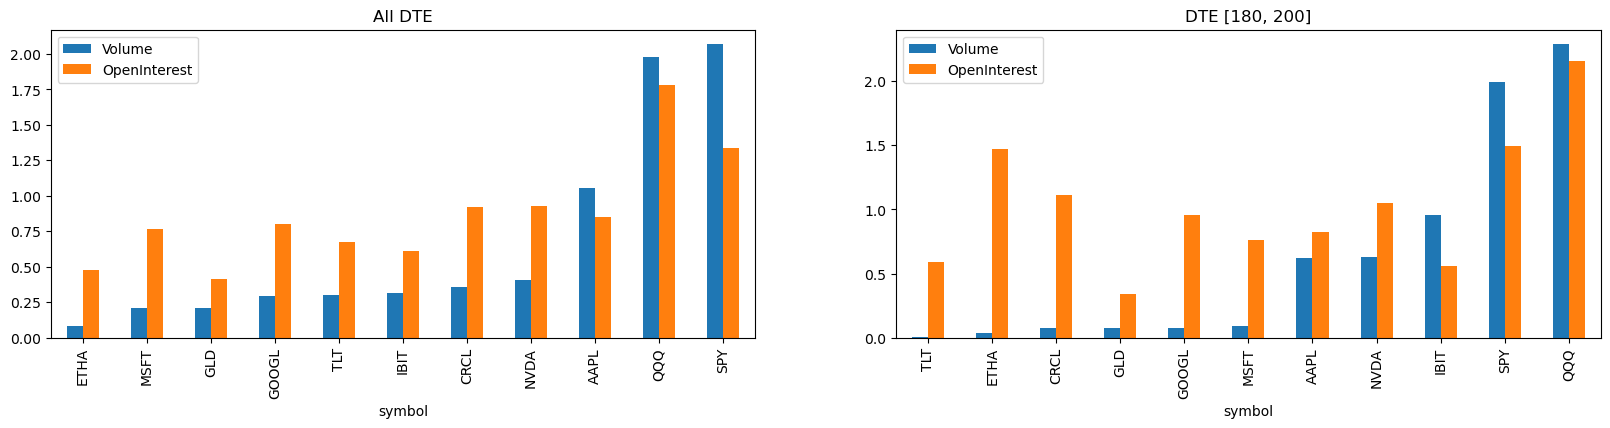

In [8]:
plot_put_call_ratios(df_cp[df_cp.symbol != 'DIA'], [180, 200])

In [43]:
def plot_leverage_pct_theta(df, delta_lb=0.5, overpaid_ub=0.1, price_lb=5, spread_ub=10, leverage_lb=2, openinterest_lb=10):
    _filter = (df.Delta >= delta_lb) & (df.overpaid <= overpaid_ub) & (df.mid >= price_lb) & (df.pctSpread <= spread_ub)
    _filter = _filter & (df.leverage >= leverage_lb) & (df.OpenInterest >= openinterest_lb)
    _df = df[_filter].set_index(['symbol', 'expDt']).sort_values(by='leverage', ascending=False)
    _symlist = list(_df.index.get_level_values('symbol').unique())
    nr = 1 if len(_symlist) <= 4 else int(np.ceil(len(_symlist)/4))
    nc = int(np.ceil(len(_symlist)/nr))
    plt.rcParams['figure.figsize'] = (nc*5, nr*5)
    fig, ax = plt.subplots(nr, nc)
    for i, symbol in enumerate(_symlist):
        _dte = sorted(_df.loc[symbol].dte.unique())
        print(symbol, len(_dte), 'DTEs', _dte)
        _title = f'{symbol} dte: {min(_dte)}~{max(_dte)}'
        if nr == 1:
            _df.xs(symbol, level='symbol').plot(kind='scatter', y='pctTheta', x='leverage', ax=ax if nc==1 else ax[i%nc], title=_title)
        else:
            _df.xs(symbol, level='symbol').plot(kind='scatter', y='pctTheta', x='leverage', ax=ax[i//nc, i%nc], title=_title)
    return _df

DIA 7 DTEs [108, 119, 198, 210, 302, 381, 409]
SPY 10 DTEs [108, 119, 149, 178, 198, 210, 290, 302, 381, 409]
TLT 10 DTEs [108, 119, 136, 164, 198, 210, 227, 290, 302, 409]
GLD 8 DTEs [108, 119, 164, 198, 210, 290, 302, 409]
QQQ 10 DTEs [108, 119, 136, 164, 198, 210, 290, 302, 381, 409]
MSFT 8 DTEs [108, 136, 164, 198, 227, 290, 381, 409]
AAPL 8 DTEs [108, 136, 164, 198, 227, 290, 381, 409]
GOOGL 8 DTEs [108, 136, 164, 198, 227, 290, 381, 409]
NVDA 6 DTEs [108, 136, 164, 198, 227, 290]
IBIT 3 DTEs [108, 164, 198]
CRCL 1 DTEs [108]
ETHA 1 DTEs [108]


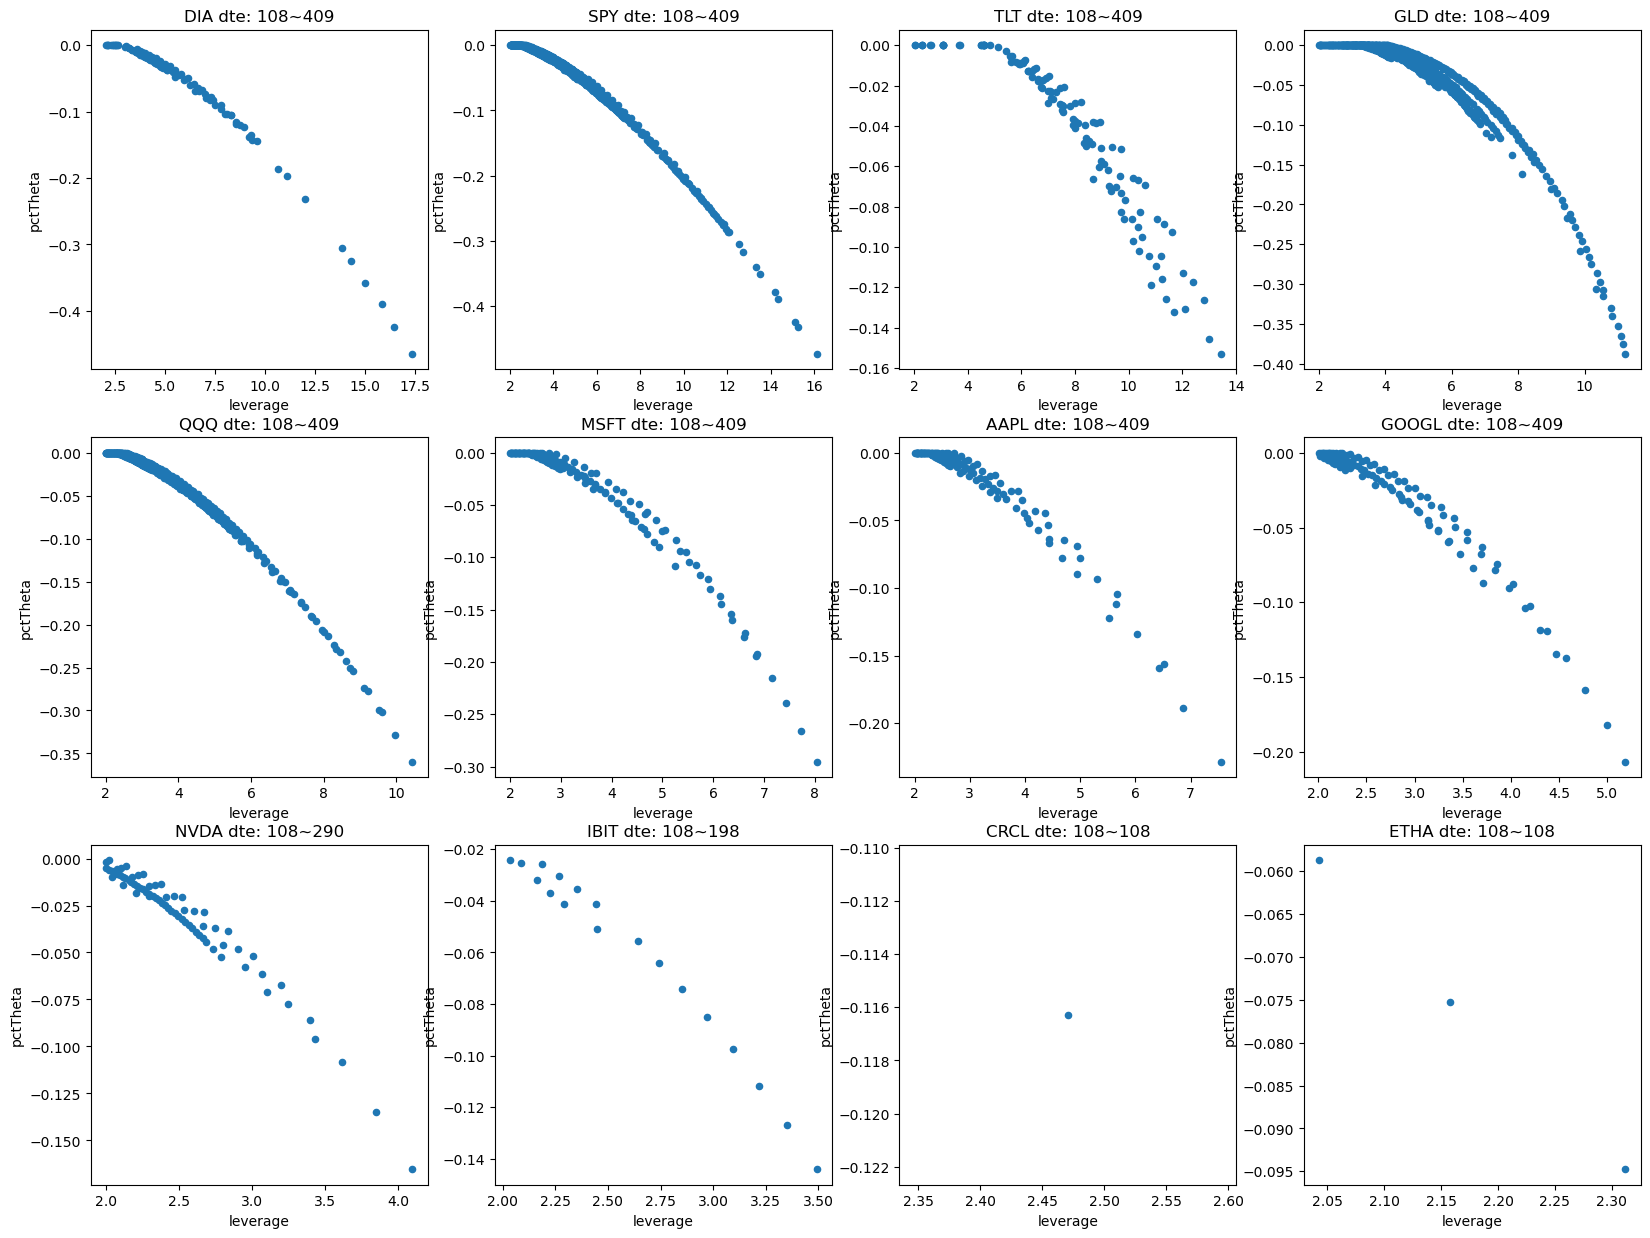

In [44]:
_df = plot_leverage_pct_theta(df_cp, delta_lb=0.5, overpaid_ub=0.05, price_lb=5, spread_ub=10, leverage_lb=2, openinterest_lb=10)

DIA 7 DTEs [108, 119, 198, 210, 302, 381, 409]
SPY 10 DTEs [108, 119, 149, 178, 198, 210, 290, 302, 381, 409]
TLT 10 DTEs [108, 119, 136, 164, 198, 210, 227, 290, 302, 409]
GLD 8 DTEs [108, 119, 164, 198, 210, 290, 302, 409]
QQQ 10 DTEs [108, 119, 136, 164, 198, 210, 290, 302, 381, 409]
MSFT 8 DTEs [108, 136, 164, 198, 227, 290, 381, 409]
AAPL 8 DTEs [108, 136, 164, 198, 227, 290, 381, 409]
GOOGL 8 DTEs [108, 136, 164, 198, 227, 290, 381, 409]
NVDA 6 DTEs [108, 136, 164, 198, 227, 290]
IBIT 3 DTEs [108, 164, 198]
CRCL 1 DTEs [108]
ETHA 1 DTEs [108]


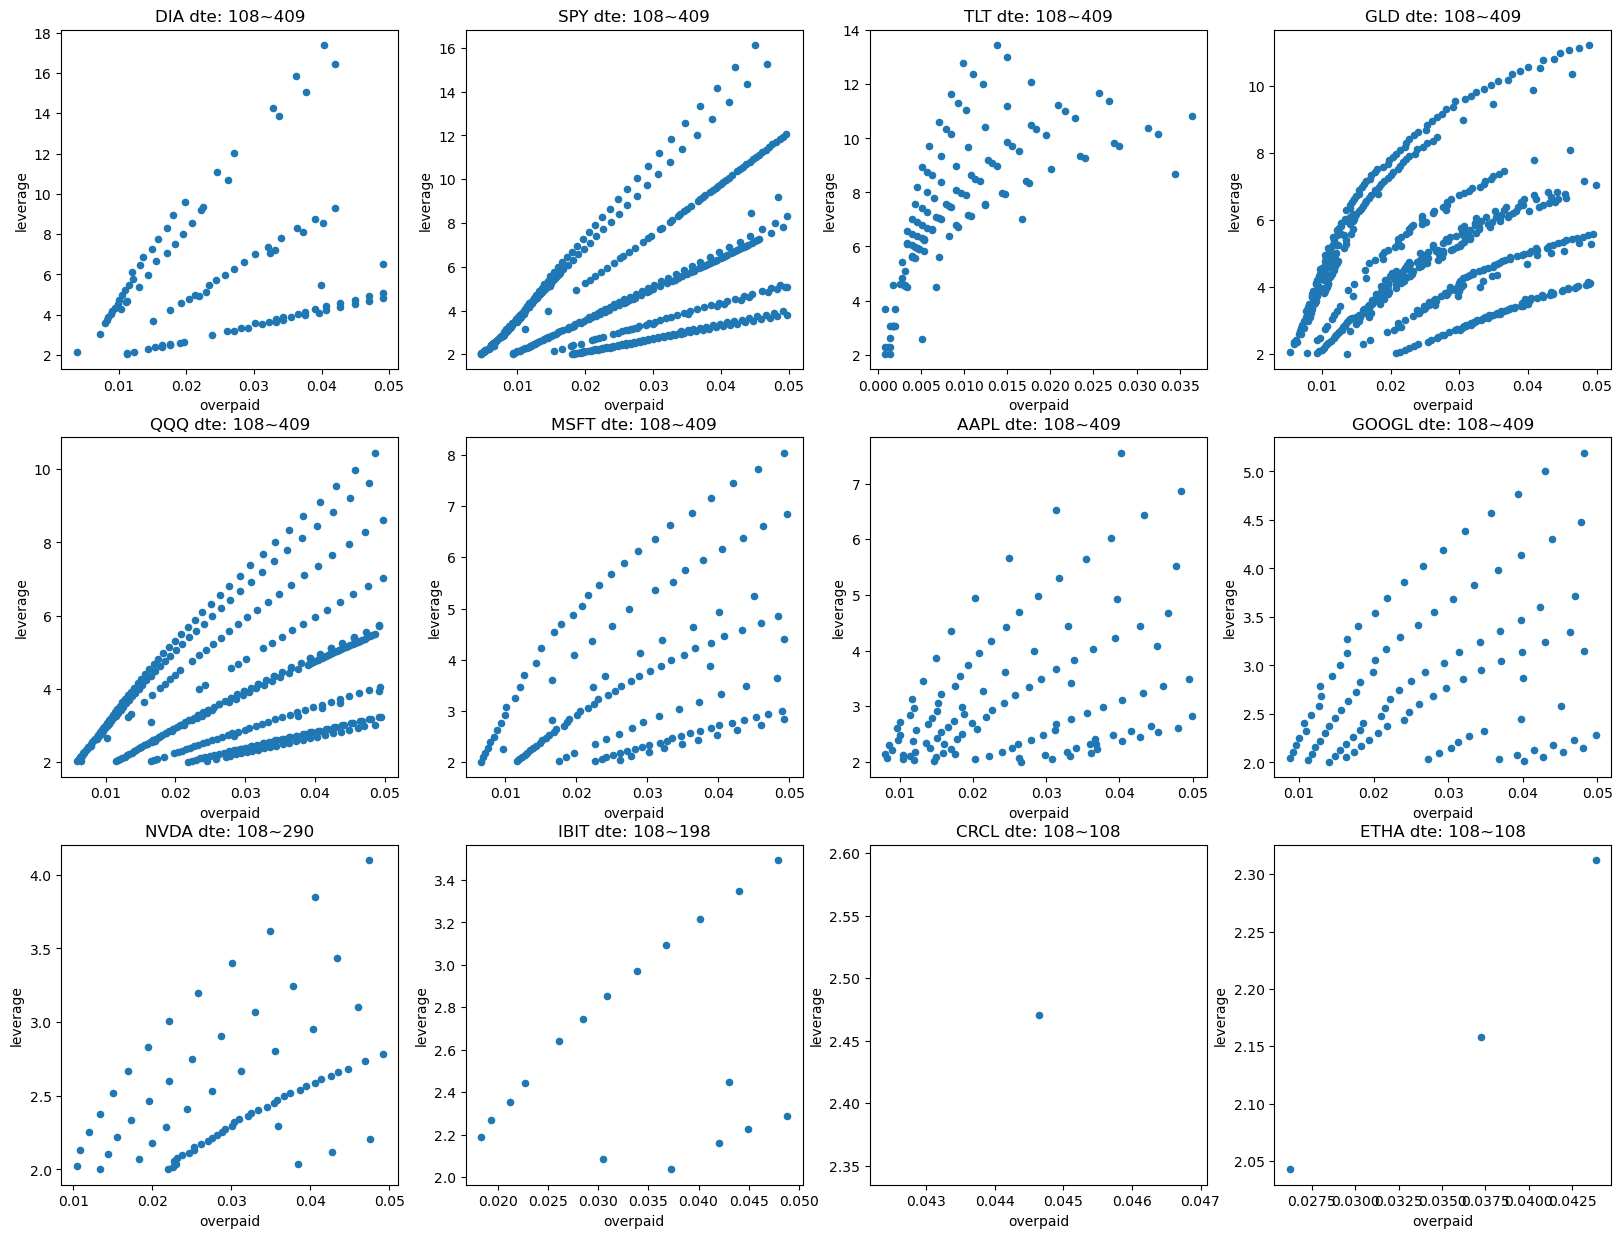

In [45]:
_df = plot_leverage_overpaid(df_cp, delta_lb=0.5, overpaid_ub=0.05, price_lb=5, spread_ub=10, leverage_lb=2, openinterest_lb=10)

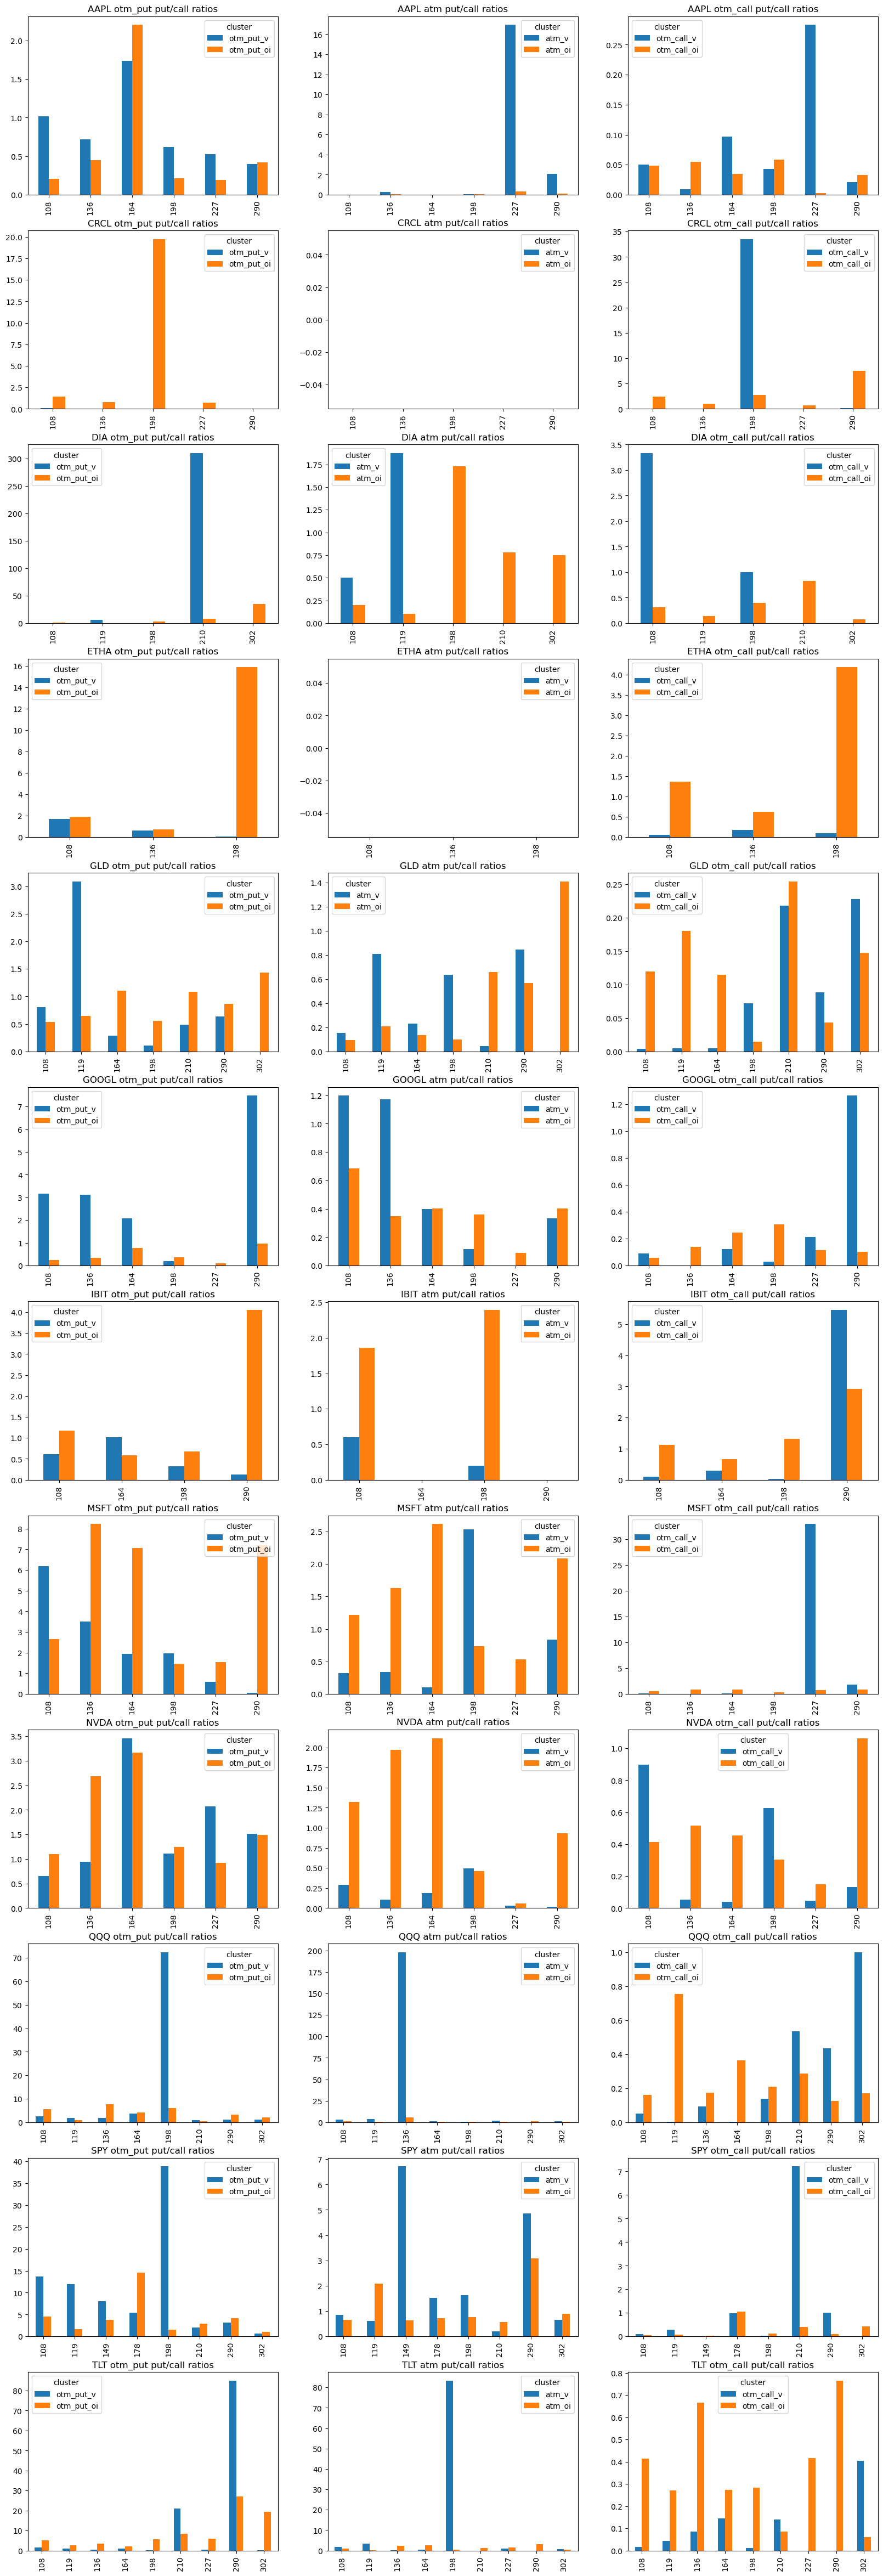

In [46]:
dte_filter = (df_cp.dte >= 90) & (df_cp.dte <= 360)
df_moneyness = add_moneyness_columns(df_cp[dte_filter].copy(), atm_offset=0.01, otm_offset=0.1)
_df = plot_put_call_ratios_by_moneyness(df_moneyness)

In [47]:
_df[_df.symbol=='GLD']

cluster,symbol,dte,deep_otm_put_v,otm_put_v,atm_v,otm_call_v,deep_otm_call_v,deep_otm_put_oi,otm_put_oi,atm_oi,otm_call_oi,deep_otm_call_oi
19,GLD,108,18.530303,0.800813,0.154321,0.003552,0.049399,2.425139,0.531292,0.094178,0.119038,0.002221
20,GLD,119,29.000000,3.087719,0.808219,0.004886,0.001587,2.002133,0.640661,0.207822,0.179915,0.011412
21,GLD,164,1.666667,0.290323,0.232143,0.004988,0.000000,1.828382,1.102187,0.137112,0.114784,0.010411
22,GLD,198,1.064516,0.102941,0.636364,0.072046,0.000000,1.105276,0.553823,0.098857,0.014643,0.006909
23,GLD,210,0.250000,0.482759,0.045455,0.217391,0.000000,0.970349,1.083878,0.659686,0.253987,0.511208
24,GLD,290,0.566038,0.636364,0.846154,0.088462,0.000000,2.136678,0.861064,0.566810,0.042917,0.001018
25,GLD,302,4.000000,0.000000,0.000000,0.227273,0.000000,5.499168,1.432200,1.411215,0.146885,0.030405


GLD 1 DTEs [108]


,dte,strike,lastPrice,pctSpread,Delta,Volume,ImpVola,OpenInterest,Gamma,Theta,Vega,Rho,type,mid,overpaid,leverage,pctTheta
expDt,,,,,,,,,,,,,,,,,
2026-03-20,108,341.0,384.61,3.699897,0.88718,2,0.20333,102,0.00436,-0.03132,0.40590,0.86372,C,49.550,0.015444,6.886343,-0.063209
2026-03-20,108,338.0,384.61,3.307393,0.89975,0,0.20707,105,0.00397,-0.02806,0.37336,0.87004,C,52.250,0.014664,6.623021,-0.053703
2026-03-20,108,347.0,384.61,3.903559,0.85831,0,0.20127,109,0.00520,-0.03799,0.47483,0.84621,C,44.400,0.017654,7.435014,-0.085563
2026-03-20,108,298.0,384.61,2.584270,0.97668,0,0.24999,153,0.00098,-0.00090,0.11398,0.84419,C,90.150,0.009204,4.166843,-0.000998
2026-03-20,108,336.0,384.61,3.195489,0.90731,0,0.20850,159,0.00372,-0.02603,0.35253,0.87338,C,54.050,0.014144,6.456253,-0.048159
2026-03-20,108,313.0,384.61,3.085178,0.96148,0,0.23416,167,0.00166,-0.00813,0.17635,0.87036,C,75.700,0.010634,4.885004,-0.010740
2026-03-20,108,265.0,384.61,2.981366,0.99019,0,0.31525,174,0.00035,0.00000,0.04886,0.76293,C,122.550,0.007644,3.107605,0.000000
2026-03-20,108,307.0,384.61,2.800249,0.96891,0,0.24191,189,0.00134,-0.00483,0.14699,0.86155,C,81.475,0.010049,4.573826,-0.005928
2026-03-20,108,285.0,384.61,3.509639,0.98405,0,0.27780,196,0.00064,0.00000,0.08000,0.81459,C,102.925,0.008619,3.677197,0.000000


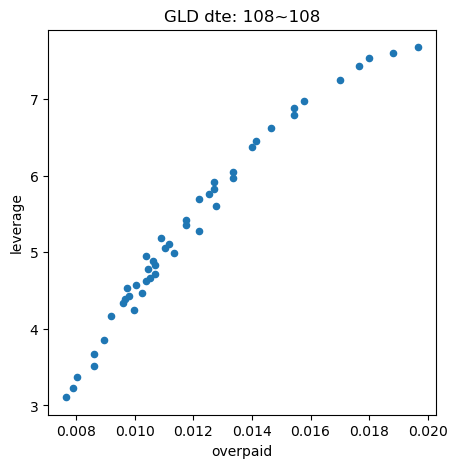

In [52]:
_symbol = 'GLD'
_df2 = df_cp[(df_cp.symbol==_symbol) & (df_cp.dte == 108) & (df_cp.strike >= 200) & (df_cp.pctTheta >= -0.1)]
plot_leverage_overpaid(_df2, delta_lb=0.5, overpaid_ub=0.05, price_lb=1, spread_ub=10, leverage_lb=3, openinterest_lb=100).loc[_symbol].sort_values(by='OpenInterest').tail(60)

red: put, green: call


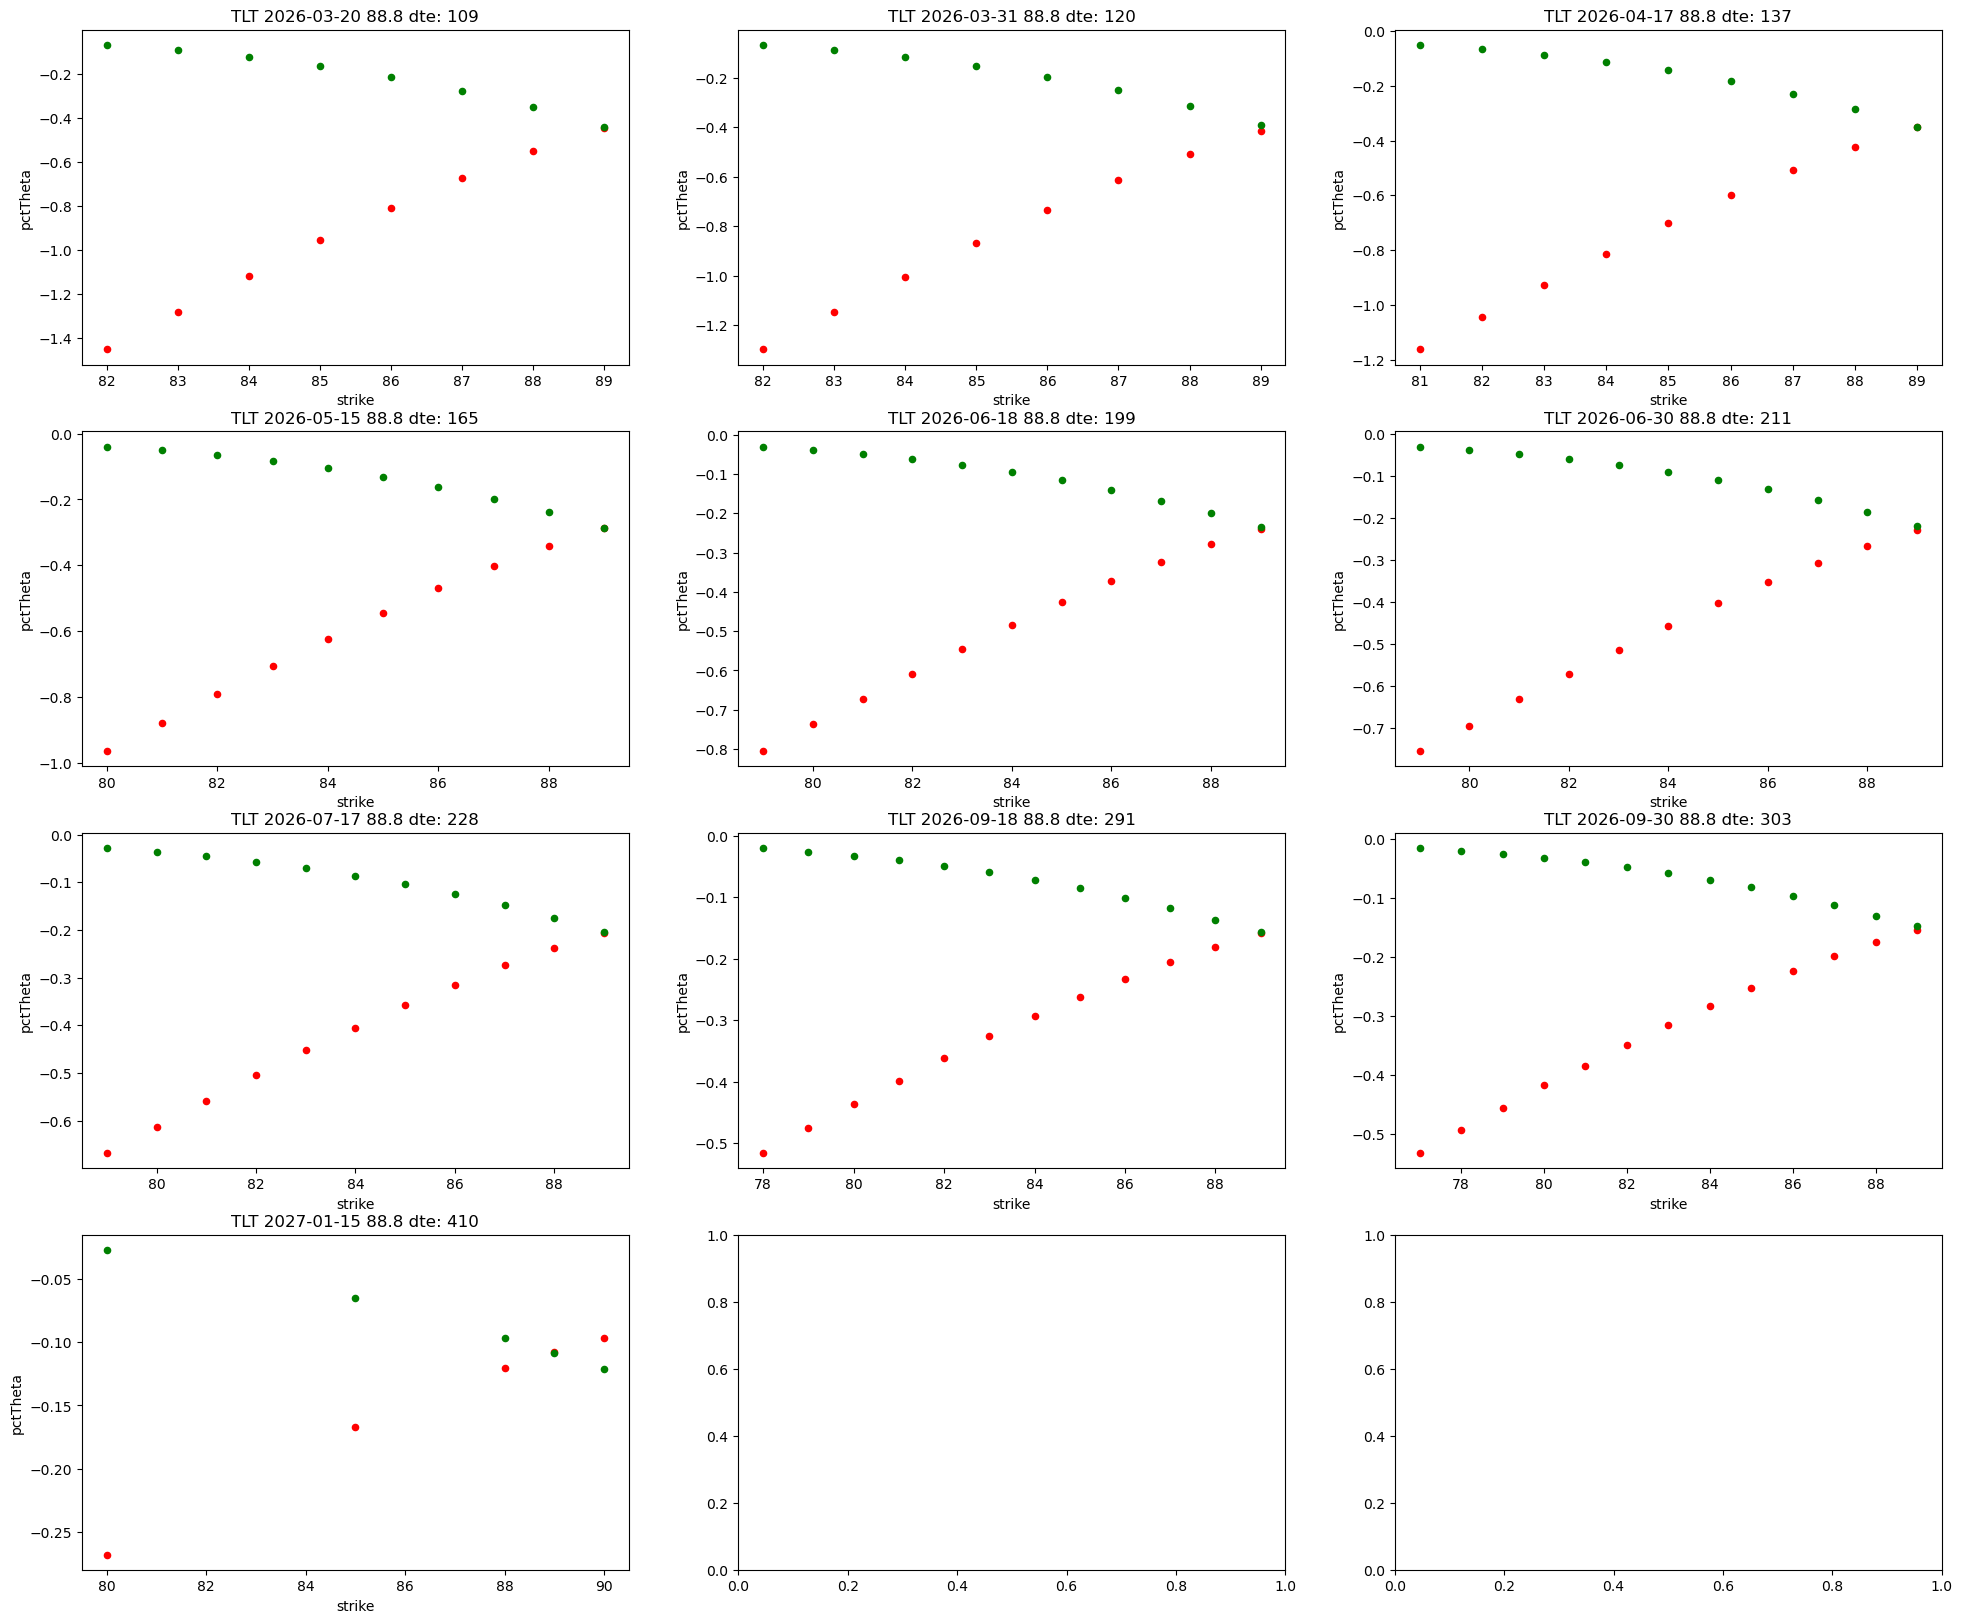

In [63]:
plot_option_details_by_dte(df_cp, 'TLT', 'pctTheta', delta_lb=0.5, delta_ub=0.9, nr=4, nc=3)

In [13]:
df_cp.columns

Index(['symbol', 'dte', 'strike', 'lastPrice', 'pctSpread', 'Delta', 'Volume',
       'ImpVola', 'OpenInterest', 'Gamma', 'Theta', 'Vega', 'Rho', 'expDt',
       'type', 'mid', 'overpaid', 'leverage', 'moneyness', 'cluster'],
      dtype='object')

red: put, green: call


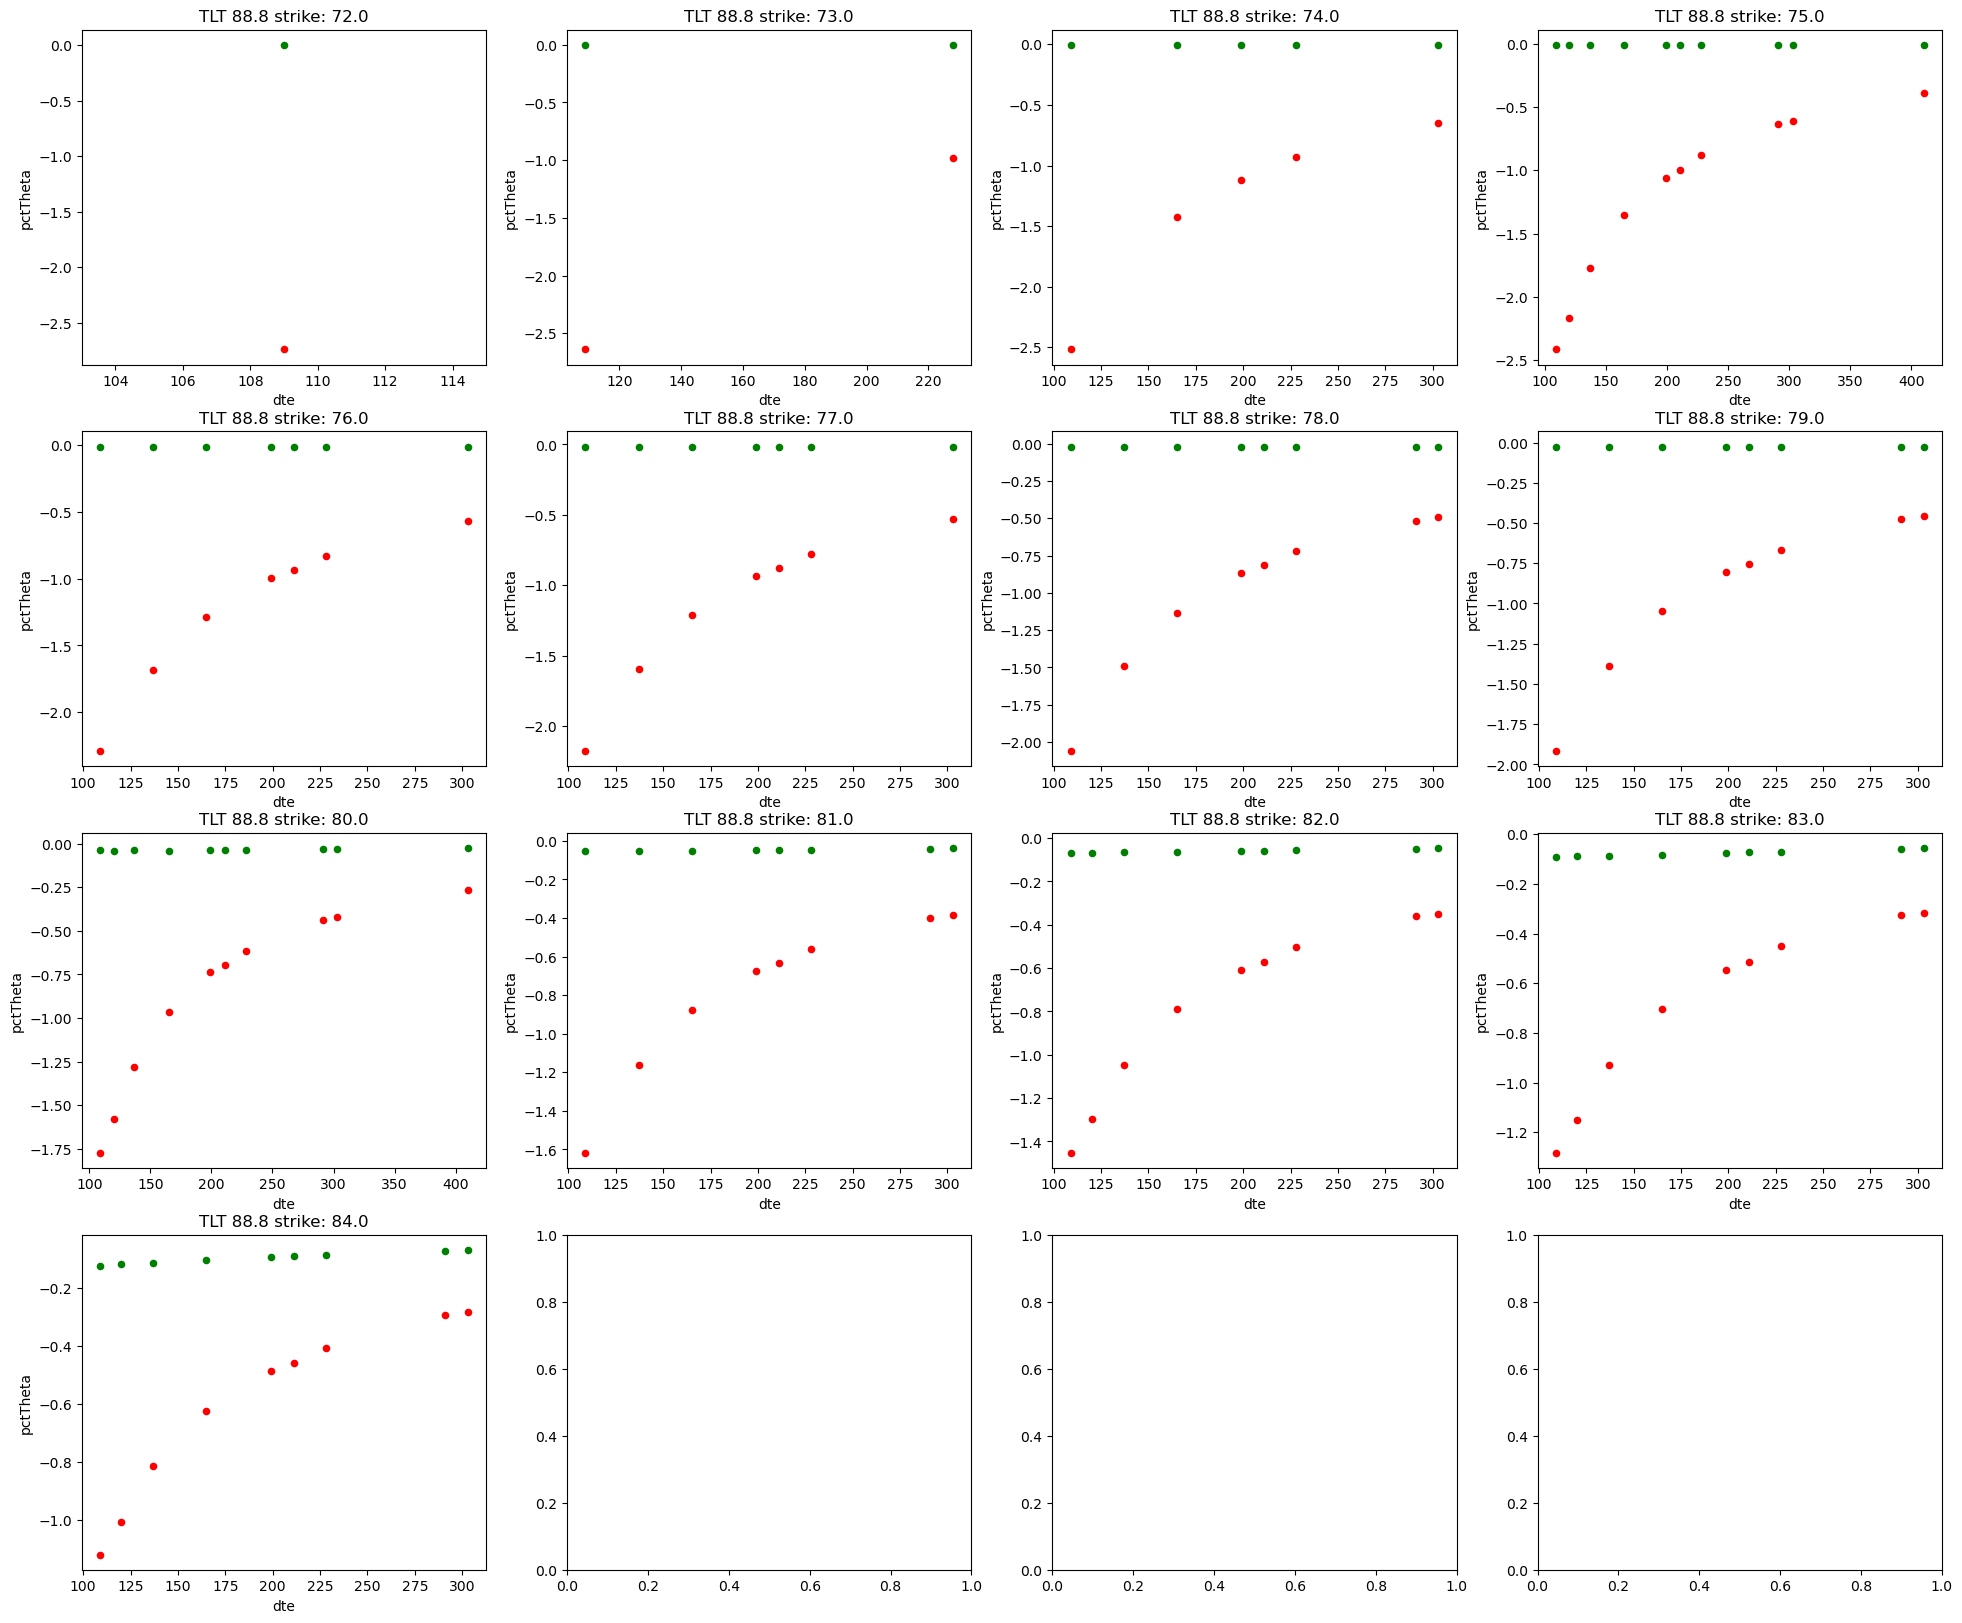

In [64]:
plot_option_details_by_strike(df_cp, 'TLT', 'pctTheta', [0.8, 0.95])

### The End